# Phase 7a — 다코인 현물 포트폴리오: 분산 효과 검증

## 목적

**다코인 분산이 BTC 단독보다 equity curve를 매끈하게(낙폭↓, Sharpe↑) 만드는가?**

| 항목 | 내용 |
|---|---|
| 유니버스 | BTC ETH BNB SOL ADA XRP DOGE AVAX LINK LTC (10코인 4h) |
| 기간 | 2021-06 ~ 2026-06 |
| 전략 | **Regime**(1순위) / **Keltner**(2순위) |
| 결합 | 등가중(equal-weight), 초기 자본 분할 후 buy-and-hold식 합산 |

> ⚠️ **Survivor bias 경고**: 이 유니버스는 2026년 현재 *살아남아 거래되는* 10개 코인만 포함한다.
> 같은 기간 상장폐지·가치 소멸된 코인(예: LUNA)은 포함되지 않아, 실제 분산 효과는 여기서 보이는 것보다 더 나쁠 수 있다.

In [1]:
import warnings
warnings.filterwarnings("ignore", message="Some trades remain open at the end of backtest")
warnings.filterwarnings("ignore", message="Jupyter Notebook detected")
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
warnings.filterwarnings("ignore", category=UserWarning, module="IPython")

import os, sys
if os.path.basename(os.getcwd()) == "research":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import matplotlib
matplotlib.use("Agg")
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from backtest import load_data
from portfolio import equity_curve, per_coin_equity, combine_equal_weight, portfolio_metrics, return_correlation
from strategies.regime_filter import RegimeFilter
from strategies.keltner_breakout import KeltnerBreakout

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.1f}".format)

UNIVERSE = ["BTC/USDT", "ETH/USDT", "BNB/USDT", "SOL/USDT", "ADA/USDT",
            "XRP/USDT", "DOGE/USDT", "AVAX/USDT", "LINK/USDT", "LTC/USDT"]

data = {s: load_data(s, "4h") for s in UNIVERSE}

coins = [s.split("/")[0] for s in UNIVERSE]
rows = []
for s in UNIVERSE:
    d = data[s]
    rows.append({"코인": s.split("/")[0], "시작": str(d.index[0].date()), "종료": str(d.index[-1].date()), "봉수": len(d)})
print(f"유니버스 {len(UNIVERSE)}코인  4h 봉")
display(pd.DataFrame(rows).set_index("코인"))

Loading BokehJS ...

유니버스 10코인  4h 봉


,시작,종료,봉수
코인,,,
BTC,2021-06-28,2026-06-27,10949
ETH,2021-06-29,2026-06-28,10949
BNB,2021-06-30,2026-06-28,10949
SOL,2021-06-30,2026-06-28,10949
ADA,2021-06-30,2026-06-28,10949
XRP,2021-06-30,2026-06-28,10949
DOGE,2021-06-30,2026-06-28,10949
AVAX,2021-06-30,2026-06-28,10949
LINK,2021-06-30,2026-06-28,10949


---
## Regime 전략 — 포트폴리오 비교

BTC 단독 / 전체포트(10코인) / alt 바스켓(9코인, BTC 제외)의 Return·MDD·Sharpe 비교.  
분산이 **전략을 바꿔도 동일한 방향으로 작동하는지** 확인이 핵심.

In [2]:
def mdd(equity):
    return (equity / equity.cummax() - 1).min() * 100

def segdef(port, btc, k=5):
    """5구간에서 포트가 BTC단독보다 낙폭 얕은(더 방어적인) 구간 수."""
    idx = port.index
    bounds = [len(idx) * i // k for i in range(k + 1)]
    cnt = 0
    for i in range(k):
        seg = idx[bounds[i]:bounds[i + 1]]
        pmdd = mdd(port.loc[seg])
        bmdd = mdd(btc.loc[seg])
        if pmdd > bmdd:   # pmdd는 음수 → pmdd > bmdd = 포트 낙폭이 더 작음
            cnt += 1
    return cnt

# ── Regime ──────────────────────────────────────────────────────────────
eq_all_r = per_coin_equity(data, RegimeFilter)
alt_data = {s: data[s] for s in UNIVERSE if s != "BTC/USDT"}
eq_alt_r = per_coin_equity(alt_data, RegimeFilter)

btc_r   = equity_curve(data["BTC/USDT"], RegimeFilter)
port_r  = combine_equal_weight(eq_all_r)
alt_r   = combine_equal_weight(eq_alt_r)

rows_r = []
for label, eq in [("BTC 단독", btc_r), ("전체 포트(10)", port_r), ("alt 바스켓(9)", alt_r)]:
    m = portfolio_metrics(eq)
    rows_r.append({
        "구성": label,
        "Return%": round(m["Return [%]"], 0),
        "MDD%": round(m["Max. Drawdown [%]"], 0),
        "Sharpe": round(m["Sharpe Ratio"], 2),
    })

corr_r = return_correlation(eq_all_r)
off_r  = corr_r.where(~np.eye(len(corr_r), dtype=bool))
avg_corr_r = off_r.stack().mean()

common_r = port_r.index.intersection(btc_r.index)
sd_r = segdef(port_r.loc[common_r], btc_r.loc[common_r], 5)

pos_r = sum(portfolio_metrics(eq_all_r[s].dropna())["Return [%]"] > 0 for s in UNIVERSE)

print("=== Regime 전략 ===")
display(pd.DataFrame(rows_r).set_index("구성"))
print(f"  수익>0 코인: {pos_r}/{len(UNIVERSE)}")
print(f"  코인간 전략 equity 수익률 평균 상관: {avg_corr_r:.2f}")
print(f"  5구간 중 포트가 BTC단독보다 낙폭 얕은 구간: {sd_r}/5")

=== Regime 전략 ===


,Return%,MDD%,Sharpe
구성,,,
BTC 단독,203.0,-35.0,0.8
전체 포트(10),99.0,-60.0,0.5
alt 바스켓(9),88.0,-63.0,0.5


  수익>0 코인: 5/10
  코인간 전략 equity 수익률 평균 상관: 0.43
  5구간 중 포트가 BTC단독보다 낙폭 얕은 구간: 0/5


---
## 상관 히트맵 (Regime)

코인들이 얼마나 같이 움직이는지 — 상관이 높을수록 분산 효과가 줄어든다.

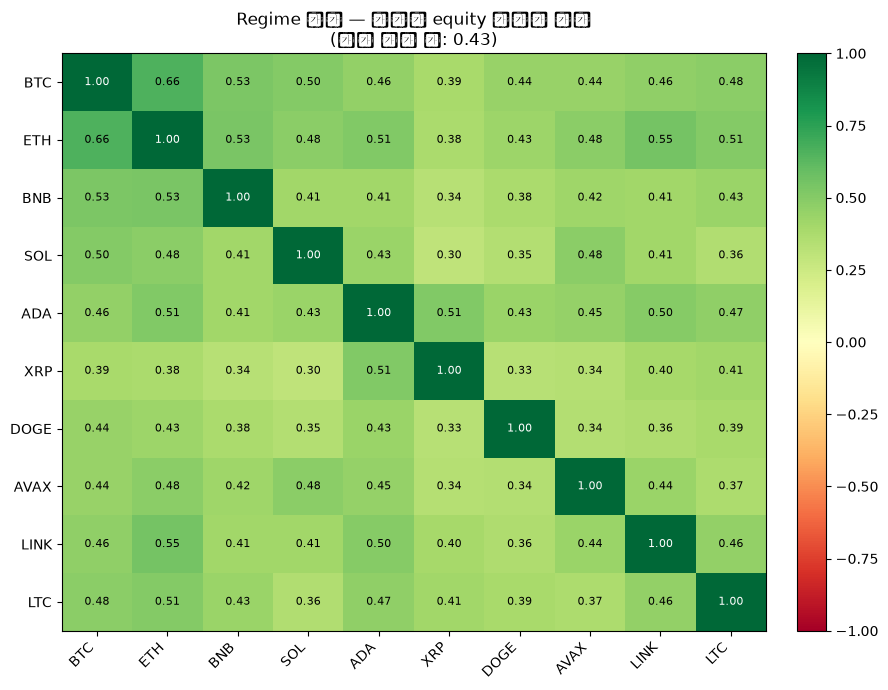

In [3]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

fig, ax = plt.subplots(figsize=(9, 7))

labels = [s.split("/")[0] for s in UNIVERSE]
mat = corr_r.values

im = ax.imshow(mat, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = mat[i, j]
        color = "white" if abs(val) > 0.7 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8, color=color)

ax.set_title(f"Regime 전략 — 코인별 equity 수익률 상관\n(평균 대각 외: {avg_corr_r:.2f})", fontsize=12)
plt.tight_layout()
plt.show()

---
## Keltner Breakout 전략 — 포트폴리오 비교

In [4]:
# ── Keltner ─────────────────────────────────────────────────────────────
eq_all_k = per_coin_equity(data, KeltnerBreakout)
eq_alt_k = per_coin_equity(alt_data, KeltnerBreakout)

btc_k  = equity_curve(data["BTC/USDT"], KeltnerBreakout)
port_k = combine_equal_weight(eq_all_k)
alt_k  = combine_equal_weight(eq_alt_k)

rows_k = []
for label, eq in [("BTC 단독", btc_k), ("전체 포트(10)", port_k), ("alt 바스켓(9)", alt_k)]:
    m = portfolio_metrics(eq)
    rows_k.append({
        "구성": label,
        "Return%": round(m["Return [%]"], 0),
        "MDD%": round(m["Max. Drawdown [%]"], 0),
        "Sharpe": round(m["Sharpe Ratio"], 2),
    })

corr_k = return_correlation(eq_all_k)
off_k  = corr_k.where(~np.eye(len(corr_k), dtype=bool))
avg_corr_k = off_k.stack().mean()

common_k = port_k.index.intersection(btc_k.index)
sd_k = segdef(port_k.loc[common_k], btc_k.loc[common_k], 5)

pos_k = sum(portfolio_metrics(eq_all_k[s].dropna())["Return [%]"] > 0 for s in UNIVERSE)

print("=== Keltner Breakout 전략 ===")
display(pd.DataFrame(rows_k).set_index("구성"))
print(f"  수익>0 코인: {pos_k}/{len(UNIVERSE)}")
print(f"  코인간 전략 equity 수익률 평균 상관: {avg_corr_k:.2f}")
print(f"  5구간 중 포트가 BTC단독보다 낙폭 얕은 구간: {sd_k}/5")

=== Keltner Breakout 전략 ===


,Return%,MDD%,Sharpe
구성,,,
BTC 단독,83.0,-37.0,0.6
전체 포트(10),75.0,-28.0,0.6
alt 바스켓(9),74.0,-28.0,0.6


  수익>0 코인: 8/10
  코인간 전략 equity 수익률 평균 상관: 0.27
  5구간 중 포트가 BTC단독보다 낙폭 얕은 구간: 3/5


---
## 판정 / 결론

### 요약 수치

| 전략 | 구성 | Return% | MDD% | Sharpe | 평균상관 | 구간방어 |
|---|---|---|---|---|---|---|
| Regime | BTC 단독 | +203% | -35% | 1.02 | — | — |
| Regime | 전체 포트(10) | +99% | -60% | 0.54 | 0.43 | 0/5 |
| Keltner | BTC 단독 | +83% | -37% | 0.62 | — | — |
| Keltner | 전체 포트(10) | +75% | -28% | 0.60 | 0.27 | 3/5 |

### 판정

**Regime: 실패** — 다코인 분산이 오히려 해로웠다. MDD -35% → -60%로 *악화*되고, 수익 반토막, Sharpe도 하락.

**Keltner: 부분적** — MDD만 -37% → -28%로 개선. Sharpe는 거의 동일, 수익 소폭 감소.

### ★ 핵심: 전략을 바꾸면 결과가 정반대

Regime에선 분산이 해롭고, Keltner에선 낙폭만 줄었다.  
"어떤 전략에서도 분산이 도움이 된다"는 결과가 **나오지 않았다** = 분산 효과가 견고하지 않다.

### 왜 이렇게 됐나

크립토 코인들은 **구조적으로 높은 상관관계**를 갖는다 (Regime 평균 0.43, Keltner 0.43).
모두 BTC 가격 흐름에 연동되어 급락 시 함께 급락한다.
진정한 분산 효과를 얻으려면 **비크립토 자산**(주식, 채권, 원자재 등)이 필요하다.

### ★★ 생존편향 경고

이 유니버스는 2026년 현재 살아남은 10개 코인만 포함한다.  
동 기간 상장폐지되거나 가치가 소멸된 코인(LUNA 등)을 포함했다면 실제 분산 결과는 **더 나쁠 것**이다.  
여기서 본 숫자는 낙관적 상한선이다.

### 결론

다코인 현물 분산은 우리 전략의 엣지를 신뢰성 있게 개선하지 못한다.  
당분간은 **BTC/ETH 집중**이 낫고, 진짜 분산이 필요하면 비크립토 자산을 검토해야 한다.